# Uses 'DecisionTree.csv'

In [1]:
import csv
from random import randint
import random

header = ['SubjID', 'Decision1', 'Decision2', 'Decision3', 'HealthStatus', 'Bias']
data = []
d1 = 0
d2 = 0
d3 = 0

health = 0 
health_vals = [75, 80, 85, 90, 95, 100]

bias_vals = [0, 1]
bias = 0

for i in range(1, 61):
    health = 100    
    d1 = randint(0, 5)
    d2 = randint(0, 5)
    d3 = randint(0, 5)
    health = random.choice(health_vals) 
    bias = random.choice(bias_vals) 
    
    data.append([i, d1, d2, d3, health, bias])

with open('DecisionTree.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(data)

In [3]:
import pandas as pd
data = pd.read_csv('DecisionTree.csv')
data.columns

Index(['SubjID', 'Decision1', 'Decision2', 'Decision3', 'HealthStatus',
       'Bias'],
      dtype='object')

In [4]:
data.head()

,SubjID,Decision1,Decision2,Decision3,HealthStatus,Bias
0,1,4,1,2,90,1
1,2,2,3,5,90,0
2,3,2,3,3,90,1
3,4,2,1,4,75,1
4,5,0,5,2,80,1


In [15]:
import numpy as np
y=data.Bias.values
#normalization
x_data=data.drop(["Bias"], axis=1)
x=(x_data-np.min(x_data))/(np.max(x_data) -np.min(x_data))

In [7]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

In [9]:
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier()
dt.fit(x_train,y_train)
print("score :",dt.score(x_test,y_test))

score : 0.8888888888888888


In [10]:
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree

In [23]:
y=data.Bias.values
#normalization
x_data=data.drop(["Bias"], axis=1)
x=(x_data-np.min(x_data))/(np.max(x_data) -np.min(x_data))

clf = DecisionTreeClassifier(random_state=1234)
model = clf.fit(x, y)

In [24]:
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_3 <= 0.10
|   |--- class: 1
|--- feature_3 >  0.10
|   |--- feature_0 <= 0.11
|   |   |--- feature_0 <= 0.03
|   |   |   |--- feature_3 <= 0.70
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.70
|   |   |   |   |--- class: 0
|   |   |--- feature_0 >  0.03
|   |   |   |--- class: 1
|   |--- feature_0 >  0.11
|   |   |--- feature_0 <= 0.75
|   |   |   |--- feature_0 <= 0.42
|   |   |   |   |--- feature_2 <= 0.90
|   |   |   |   |   |--- feature_2 <= 0.10
|   |   |   |   |   |   |--- feature_4 <= 0.70
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_4 >  0.70
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_2 >  0.10
|   |   |   |   |   |   |--- feature_2 <= 0.70
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- feature_2 >  0.70
|   |   |   |   |   |   |   |--- feature_3 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_3 >  0.50
|   |   |  

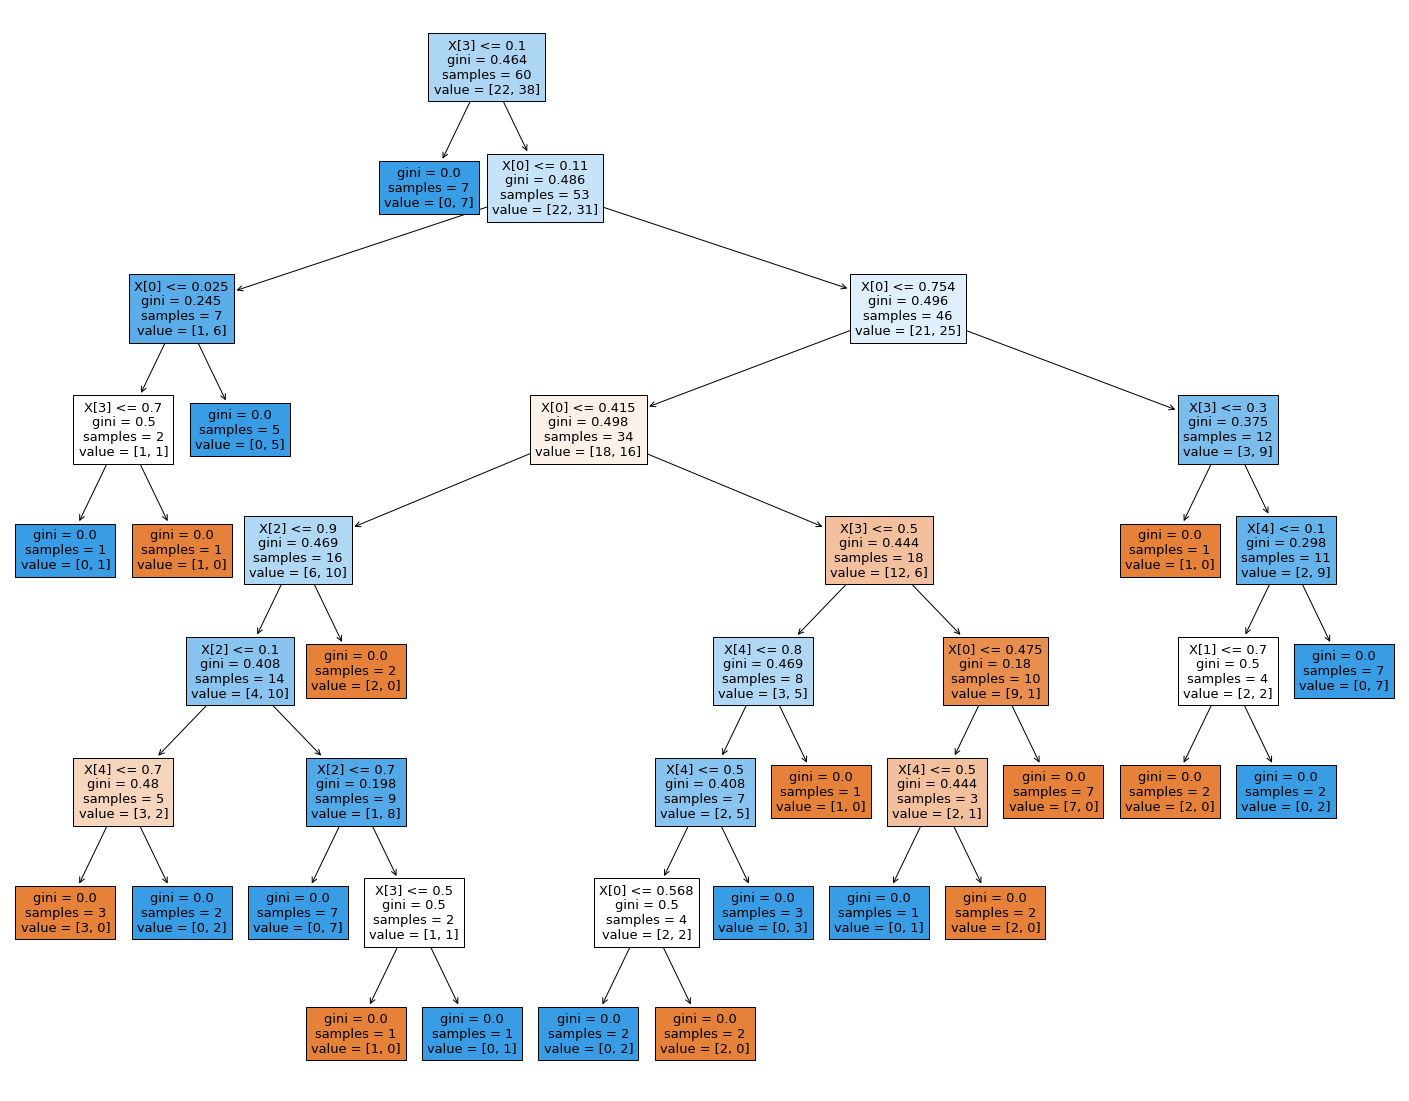

In [25]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(clf,         
                   filled=True)